In [8]:
#Task 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
from google.colab import files
uploaded = files.upload()

Saving hotel bookings.zip to hotel bookings.zip


In [10]:
import zipfile
import io

# Assuming the zip file is named 'archive (3).zip' and contains 'hotel_bookings.csv'
zip_file_name = list(uploaded.keys())[0]
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as zf:
    zf.extractall()

df = pd.read_csv("hotel_bookings.csv") # Note: Changed filename to 'hotel_bookings.csv' without space if that's the actual name in the zip
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [11]:
print(df.shape)

(119390, 32)


In [12]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [13]:
features = ['lead_time', 'adr', 'adults', 'children']
X = df[features]
X = X.fillna(0)

In [14]:
from sklearn.model_selection import train_test_split

y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
X.head()

,lead_time,adr,adults,children
0,342,0.0,2,0.0
1,737,0.0,2,0.0
2,7,75.0,1,0.0
3,13,75.0,1,0.0
4,14,98.0,2,0.0


In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [17]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 1]


In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6606918502387135
Confusion Matrix:
 [[13122  1785]
 [ 6317  2654]]


In [19]:
#Task 2
from sklearn.datasets import make_classification
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import numpy as np

In [20]:
from sklearn.datasets import make_classification
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import numpy as np

dimensions = [2, 10, 50, 200]

for dim in dimensions:
    X, _ = make_classification(
        n_samples=500,
        n_features=dim,
        n_informative=2,   # FIXED
        n_redundant=0,
        random_state=42
    )

    distances = pdist(X)

    print(f"Dimension: {dim}")
    print(f"Min: {distances.min():.2f}")
    print(f"Max: {distances.max():.2f}")
    print(f"Mean: {distances.mean():.2f}")
    print("-"*30)

Dimension: 2
Min: 0.00
Max: 9.83
Mean: 2.38
------------------------------
Dimension: 10
Min: 1.00
Max: 10.38
Mean: 4.70
------------------------------
Dimension: 50
Min: 5.93
Max: 14.73
Mean: 10.10
------------------------------
Dimension: 200
Min: 15.97
Max: 24.37
Mean: 20.08
------------------------------


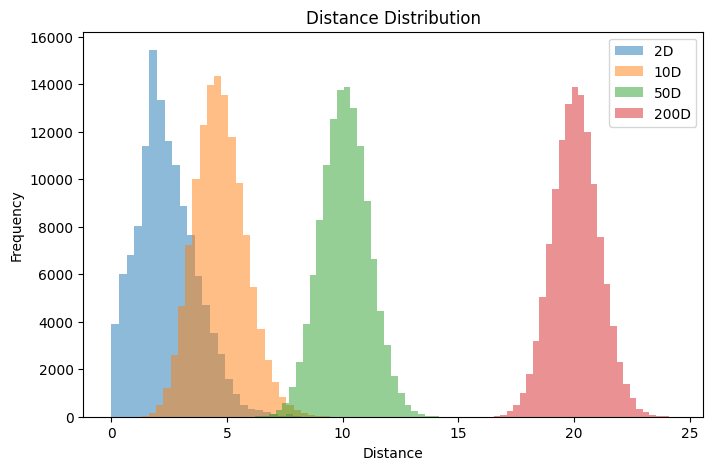

In [21]:
plt.figure(figsize=(8,5))

for dim in dimensions:
    X, _ = make_classification(
        n_samples=500,
        n_features=dim,
        n_informative=2,
        n_redundant=0,
        random_state=42
    )

    distances = pdist(X)
    plt.hist(distances, bins=30, alpha=0.5, label=f"{dim}D")

plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.title("Distance Distribution")
plt.legend()
plt.show()

In [22]:
#Task 3
num_cols = ['lead_time', 'adr', 'adults', 'children', 'stays_in_week_nights', 'stays_in_weekend_nights']

df_num = df[num_cols].copy()
df_num = df_num.fillna(0)

In [23]:
df_num['lead_time_bin'] = pd.cut(df_num['lead_time'], bins=4)
df_num['adr_bin'] = pd.qcut(df_num['adr'], q=4, duplicates='drop')
df_num['high_adr'] = (df_num['adr'] > df_num['adr'].mean()).astype(int)
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [24]:
minmax = MinMaxScaler()
standard = StandardScaler()
robust = RobustScaler()

df_minmax = minmax.fit_transform(df_num[num_cols])
df_standard = standard.fit_transform(df_num[num_cols])
df_robust = robust.fit_transform(df_num[num_cols])

In [25]:
df_minmax = pd.DataFrame(df_minmax, columns=num_cols)
df_standard = pd.DataFrame(df_standard, columns=num_cols)
df_robust = pd.DataFrame(df_robust, columns=num_cols)

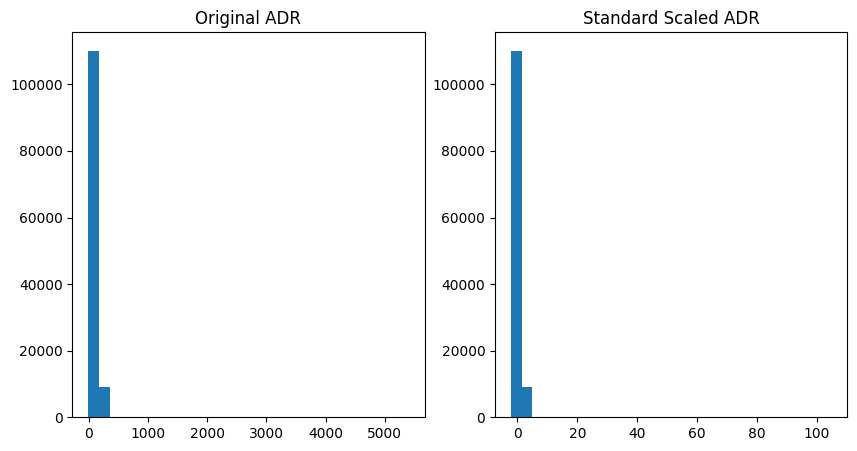

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(df_num['adr'], bins=30)
plt.title("Original ADR")

plt.subplot(1,2,2)
plt.hist(df_standard['adr'], bins=30)
plt.title("Standard Scaled ADR")

plt.show()

In [27]:
print("Original:\n", df_num.describe())
print("\nStandard Scaled:\n", df_standard.describe())

Original:
            lead_time            adr         adults       children  \
count  119390.000000  119390.000000  119390.000000  119390.000000   
mean      104.011416     101.831122       1.856403       0.103886   
std       106.863097      50.535790       0.579261       0.398555   
min         0.000000      -6.380000       0.000000       0.000000   
25%        18.000000      69.290000       2.000000       0.000000   
50%        69.000000      94.575000       2.000000       0.000000   
75%       160.000000     126.000000       2.000000       0.000000   
max       737.000000    5400.000000      55.000000      10.000000   

       stays_in_week_nights  stays_in_weekend_nights       high_adr  
count         119390.000000            119390.000000  119390.000000  
mean               2.500302                 0.927599       0.421266  
std                1.908286                 0.998613       0.493764  
min                0.000000                 0.000000       0.000000  
25%              

In [28]:
#Task 4
from sklearn.model_selection import train_test_split

features = ['lead_time', 'adr', 'adults', 'children']
X = df[features].fillna(0)
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Without Scaling Accuracy:", accuracy_score(y_test, y_pred))

Without Scaling Accuracy: 0.7493927464611777


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

knn_std = KNeighborsClassifier(n_neighbors=5)
knn_std.fit(X_train_std, y_train)

y_pred_std = knn_std.predict(X_test_std)

print("StandardScaler Accuracy:", accuracy_score(y_test, y_pred_std))

StandardScaler Accuracy: 0.7506491330932239


In [31]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_rob = scaler.fit_transform(X_train)
X_test_rob = scaler.transform(X_test)

knn_rob = KNeighborsClassifier(n_neighbors=5)
knn_rob.fit(X_train_rob, y_train)

y_pred_rob = knn_rob.predict(X_test_rob)

print("RobustScaler Accuracy:", accuracy_score(y_test, y_pred_rob))

RobustScaler Accuracy: 0.7510679286372393


In [32]:
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train_std, y_train)

y_pred_manhattan = knn_manhattan.predict(X_test_std)

print("Manhattan Accuracy:", accuracy_score(y_test, y_pred_manhattan))

Manhattan Accuracy: 0.752366194823687


In [33]:
#Task 5
# Use smaller sample (VERY FAST)
df_sample = df.sample(10000, random_state=42)

X = df_sample[['lead_time', 'adr', 'adults', 'children']]
y = df_sample['is_canceled']

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
import numpy as np

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, X.columns)
])

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=500))
])

scores = cross_val_score(pipeline, X, y, cv=3)  # reduced from 5 → 3

print("Scores:", scores)
print("Mean accuracy:", scores.mean())

Scores: [0.66046791 0.66126613 0.64506451]
Mean accuracy: 0.6555995131606741


In [34]:
#Task 6
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [35]:
month_map = {
    'January':1,'February':2,'March':3,'April':4,
    'May':5,'June':6,'July':7,'August':8,
    'September':9,'October':10,'November':11,'December':12
}

df['month_num'] = df['arrival_date_month'].map(month_map)
df['is_weekend'] = (df['arrival_date_day_of_month'] % 7 >= 5).astype(int)

In [36]:
def get_season(m):
    if m in [12,1,2]:
        return "winter"
    elif m in [3,4,5]:
        return "spring"
    elif m in [6,7,8]:
        return "summer"
    else:
        return "autumn"

df['season'] = df['month_num'].apply(get_season)
df['lead_time_bucket'] = pd.cut(df['lead_time'], bins=4)
df = pd.get_dummies(df, columns=['season'], drop_first=True)

In [37]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

In [38]:
#Task 7
df['price_per_person'] = df['adr'] / (df['total_guests'] + 1)
df['requests_per_night'] = df['total_of_special_requests'] / (df['total_nights'] + 1)
df['adr_leadtime'] = df['adr'] * df['lead_time']
df['guests_nights'] = df['total_guests'] * df['total_nights']

In [39]:
df['avg_adr_country'] = df.groupby('country')['adr'].transform('mean')
df['avg_lead_hotel'] = df.groupby('hotel')['lead_time'].transform('mean')
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(df[['adr', 'lead_time']])

poly_df = pd.DataFrame(poly_features, columns=poly.get_feature_names_out(['adr', 'lead_time']))

df = pd.concat([df, poly_df], axis=1)

In [40]:
#Task 8
X = df.select_dtypes(include=np.number).fillna(0)
y = df['is_canceled']

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X, y)

importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance.head(15))

                        feature  importance
0                   is_canceled    0.702692
28              avg_adr_country    0.058389
26                 adr_leadtime    0.024476
19    total_of_special_requests    0.019349
31                    lead_time    0.018852
25           requests_per_night    0.018143
33                adr lead_time    0.018031
14                        agent    0.017980
34                  lead_time^2    0.017027
1                     lead_time    0.016840
11       previous_cancellations    0.015464
13              booking_changes    0.010131
18  required_car_parking_spaces    0.008982
17                          adr    0.006234
32                        adr^2    0.005918


In [42]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y)

mi_df = pd.DataFrame({
    'feature': X.columns,
    'MI': mi
}).sort_values(by='MI', ascending=False)

print(mi_df.head(15))

                      feature        MI
0                 is_canceled  0.669546
33              adr lead_time  0.188890
26               adr_leadtime  0.188199
24           price_per_person  0.083929
31                  lead_time  0.081308
1                   lead_time  0.081058
30                        adr  0.080724
34                lead_time^2  0.080176
17                        adr  0.080136
14                      agent  0.079054
32                      adr^2  0.078871
28            avg_adr_country  0.067989
11     previous_cancellations  0.042512
25         requests_per_night  0.040848
19  total_of_special_requests  0.039259


In [43]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

X_filtered = X.drop(columns=to_drop)

print("Removed features:", to_drop)

Removed features: ['lead_time', 'adr', 'month_num', 'total_nights', 'price_per_person', 'requests_per_night', 'adr_leadtime', 'guests_nights', 'adr', 'lead_time', 'adr lead_time', 'lead_time^2']


In [44]:
# Get top 20 features from importance
top_features = feature_importance['feature'].head(20).tolist()

# Keep only those features that exist after filtering
top_features = [f for f in top_features if f in X_filtered.columns]

# Final dataset
X_final = X_filtered[top_features]

print("Final selected features:", top_features)

Final selected features: ['is_canceled', 'avg_adr_country', 'total_of_special_requests', 'agent', 'previous_cancellations', 'booking_changes', 'required_car_parking_spaces', 'adr^2', 'arrival_date_week_number', 'arrival_date_year']
